# RQ4 – Protective role of security awareness

**Domanda di ricerca:** A parita di intensita di utilizzo dei servizi finanziari digitali, una maggiore
consapevolezza della sicurezza e associata a una minore probabilita di riportare un incidente
(truffa, phishing, uso non autorizzato della carta, transazione non riconosciuta)?



In [11]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("mode.chained_assignment", None)

PROJECT_DIR = Path("/content/drive/MyDrive/DSLAB_PROJECT")

OUTPUT_DIR = PROJECT_DIR / "RQ4_security_awareness" / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

for folder in [OUTPUT_DIR, TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Cartella dei risultati:", OUTPUT_DIR)


Cartella dei risultati: /content/drive/MyDrive/DSLAB_PROJECT/RQ4_security_awareness/outputs


## 1. Caricamento dati

Si riparte dal dataset Stata originale (non dal CSV gia ripulito di RQ1), perche servono variabili
(qp9, qp10, qk7, qs2, qs3, qs4) che non facevano parte del subset selezionato in RQ1. I controlli
demografici (eta, istruzione, lavoro, regione, urbanizzazione) vengono ricostruiti qui con le stesse
regole gia usate in RQ1, per coerenza tra le parti del progetto.

In [15]:
DATA_FILE = PROJECT_DIR / "Database_ENG.dta"

df = pd.read_stata(DATA_FILE, convert_categoricals=False)

print("Dimensione dataset originale:", df.shape)


Dimensione dataset originale: (4862, 219)


## 2. Ricostruzione dei controlli demografici (coerente con RQ1)

`work_group` accorpa gli status lavorativi con numerosita molto bassa (apprendisti, malattia, non
cercano lavoro) in "Inattivo": nella versione grezza a 9 categorie, i modelli su `internet_access`
mostravano quasi-separazione (std err > 10) proprio su queste categorie rare.

In [17]:
df["internet_access"] = df["qd14"].where(df["qd14"].isin([0, 1]), np.nan)

age_exact = df["qd7"].replace(-99, np.nan)

df["age_group"] = pd.cut(
    age_exact,
    bins=[17, 29, 39, 49, 59, 69, np.inf],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
).astype("object")

age_band_map = {1: "18-29", 2: "18-29", 3: "30-39", 4: "40-49", 5: "50-59", 6: "60-69", 7: "70+"}
missing_age = df["age_group"].isna()
df.loc[missing_age, "age_group"] = df.loc[missing_age, "qd7_a"].map(age_band_map)

age_order = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["age_group"] = pd.Categorical(df["age_group"], categories=age_order, ordered=True)

education_map_codes = {
    1: "Universita", 2: "Universita", 3: "Universita", 4: "Universita",
    5: "Secondaria superiore", 6: "Secondaria superiore",
    7: "Secondaria inferiore o meno", 8: "Secondaria inferiore o meno",
    9: "Secondaria inferiore o meno", 10: "Secondaria inferiore o meno"
}
df["education_model"] = df["qd9"].map(education_map_codes)

education_order = ["Secondaria inferiore o meno", "Secondaria superiore", "Universita"]
df["education_model"] = pd.Categorical(df["education_model"], categories=education_order, ordered=True)

work_map = {
    1: "Occupato", 2: "Occupato", 3: "Occupato",
    4: "Inattivo", 5: "Disoccupato", 6: "Pensionato",
    7: "Inattivo", 8: "Inattivo", 9: "Studente"
}
df["work_group"] = df["qd10"].map(work_map)

df["gender"] = df["qd1"].where(df["qd1"].isin([0, 1]), np.nan)
df["region"] = df["qd2"].where(df["qd2"].between(1, 5), np.nan)
df["urbanisation"] = df["qd3"].where(df["qd3"].between(1, 5), np.nan)

print("Fasce d'eta:")
print(df["age_group"].value_counts(dropna=False).sort_index())
print()
print("Istruzione:")
print(df["education_model"].value_counts(dropna=False).sort_index())
print()
##print("Lavoro:")
##print(df["work_group"].value_counts(dropna=False))


Fasce d'eta:
age_group
18-29    567
30-39    880
40-49    880
50-59    958
60-69    841
70+      736
Name: count, dtype: int64

Istruzione:
education_model
Secondaria inferiore o meno     727
Secondaria superiore           2856
Universita                     1279
Name: count, dtype: int64



## 3. Campione analitico: solo utenti Internet

RQ4 riguarda esclusivamente chi ha gia superato la fase di accesso. Le batterie QP9, QP10, QS4 sono
somministrate solo se `qd14 = 1`: filtrare qui evita di trattare i missing strutturali come non validi.

In [18]:
connected = df[df["internet_access"] == 1].copy()

connected["wght"] = pd.to_numeric(connected["wght"], errors="coerce")
connected.loc[connected["wght"].le(0), "wght"] = np.nan

print("Utenti Internet:", len(connected))


Utenti Internet: 4427


## 4. Costruzione dell'indice di intensita d'uso (digital_finance_intensity)

Stessa costruzione usata in Part 3: media riga per riga delle sette frequenze QP9 (scala 1=Never .. 4=Very often).
Si richiede che almeno 4 item su 7 siano validi per calcolare la media, altrimenti l'indice e messo a
mancante invece di essere stimato su troppo pochi item.

In [19]:
qp9_cols = ["qp9_1", "qp9_3", "qp9_4", "qp9_5", "qp9_6", "qp9_7", "qp9_10"]

qp9_clean = connected[qp9_cols].where(connected[qp9_cols].isin([1, 2, 3, 4]))

qp9_valid_count = qp9_clean.notna().sum(axis=1)

connected["digital_finance_intensity"] = qp9_clean.mean(axis=1).where(qp9_valid_count >= 4)

print(connected["digital_finance_intensity"].describe())

intensity_bins = [0, 1.5, 2.5, 3.5, 4.01]
intensity_labels = ["Non-user", "Low use", "Medium use", "Intense use"]

connected["intensity_group"] = pd.cut(
    connected["digital_finance_intensity"],
    bins=intensity_bins,
    labels=intensity_labels,
    right=False
)

print()
print(connected["intensity_group"].value_counts(dropna=False).reindex(intensity_labels))


count    4240.000000
mean        2.067091
std         0.674236
min         1.000000
25%         1.571429
50%         2.000000
75%         2.571429
max         4.000000
Name: digital_finance_intensity, dtype: float64

intensity_group
Non-user        959
Low use        2123
Medium use     1050
Intense use     108
Name: count, dtype: int64


## 5. Costruzione dell'indice di security awareness

Punto critico: gli item hanno **direzioni diverse** (alcuni protettivi, altri rischiosi; scale a volte
invertite). Prima di aggregare, ogni item viene ricodificato in modo che **valore alto = maggiore
consapevolezza**, poi standardizzato (z-score) cosi che item con scale diverse (binaria QK7 vs 1-5 QS)
pesino in modo comparabile nella media.

| Item | Fonte | Aware = | Trasformazione |
|---|---|---|---|
| qk7_4 | Vero/Falso | Falso (0) | `1 - valore` |
| qk7_5 | Vero/Falso | Vero (1) | `valore` |
| qk7_6 | Vero/Falso | Falso (0) | `1 - valore` |
| qs2_6 | 1=Always..5=Never | Never (5) | nessun flip |
| qs2_7 | 1=Always..5=Never | Always (1) | flip: `6 - valore` |
| qs2_8 | 1=Always..5=Never | Never (5) | nessun flip |
| qs3_13 | 1=Completely..5=Not at all | Completely (1) | flip: `6 - valore` |
| qs4_1 | 1=Agree..5=Disagree | Disagree (5) | nessun flip |
| qs4_2 | 1=Agree..5=Disagree | Agree (1) | flip: `6 - valore` |
| qs4_3 | 1=Agree..5=Disagree | Disagree (5) | nessun flip |

Tutte le colonne ricodificate vengono create in un unico `pd.concat` (invece di assegnazioni ripetute
colonna per colonna), per evitare frammentazione del DataFrame.

In [20]:
qk7_items = ["qk7_4", "qk7_5", "qk7_6"]
qs2_items = ["qs2_6", "qs2_7", "qs2_8"]
qs3_items = ["qs3_13"]
qs4_items = ["qs4_1", "qs4_2", "qs4_3"]

all_awareness_raw = qk7_items + qs2_items + qs3_items + qs4_items

print("Distribuzioni grezze (prima della ricodifica):")
for c in all_awareness_raw:
    print(c, connected[c].value_counts(dropna=False).sort_index().to_dict())


Distribuzioni grezze (prima della ricodifica):
qk7_4 {-99: 53, -97: 1271, 0: 1808, 1: 1295}
qk7_5 {-99: 46, -97: 989, 0: 844, 1: 2548}
qk7_6 {-99: 59, -97: 1849, 0: 1595, 1: 924}
qs2_6 {-99: 84, -98: 96, -97: 200, 1: 27, 2: 123, 3: 292, 4: 220, 5: 3385}
qs2_7 {-99: 96, -98: 220, -97: 415, 1: 308, 2: 690, 3: 1104, 4: 617, 5: 977}
qs2_8 {-99: 65, -98: 88, -97: 201, 1: 29, 2: 177, 3: 409, 4: 277, 5: 3181}
qs3_13 {-99: 98, -98: 126, -97: 237, 1: 400, 2: 1020, 3: 1430, 4: 620, 5: 496}
qs4_1 {-99.0: 24, -98.0: 56, -97.0: 585, 1.0: 123, 2.0: 730, 3.0: 1444, 4.0: 947, 5.0: 518}
qs4_2 {-99.0: 26, -98.0: 59, -97.0: 403, 1.0: 638, 2.0: 1603, 3.0: 1217, 4.0: 373, 5.0: 108}
qs4_3 {-99.0: 21, -98.0: 67, -97.0: 346, 1.0: 188, 2.0: 692, 3.0: 1212, 4.0: 1138, 5.0: 763}


In [21]:
qk7_4_clean = connected["qk7_4"].where(connected["qk7_4"].isin([0, 1]))
qk7_5_clean = connected["qk7_5"].where(connected["qk7_5"].isin([0, 1]))
qk7_6_clean = connected["qk7_6"].where(connected["qk7_6"].isin([0, 1]))

qs2_6_clean = connected["qs2_6"].where(connected["qs2_6"].between(1, 5))
qs2_7_clean = connected["qs2_7"].where(connected["qs2_7"].between(1, 5))
qs2_8_clean = connected["qs2_8"].where(connected["qs2_8"].between(1, 5))

qs3_13_clean = connected["qs3_13"].where(connected["qs3_13"].between(1, 5))

qs4_1_clean = connected["qs4_1"].where(connected["qs4_1"].between(1, 5))
qs4_2_clean = connected["qs4_2"].where(connected["qs4_2"].between(1, 5))
qs4_3_clean = connected["qs4_3"].where(connected["qs4_3"].between(1, 5))

aw = pd.concat({
    "aw_qk7_4": 1 - qk7_4_clean,          # aware se risponde Falso
    "aw_qk7_5": qk7_5_clean,              # aware se risponde Vero
    "aw_qk7_6": 1 - qk7_6_clean,          # aware se risponde Falso
    "aw_qs2_6": qs2_6_clean,              # gia allineato: Never(5)=aware
    "aw_qs2_7": 6 - qs2_7_clean,          # flip: Always(1)->5
    "aw_qs2_8": qs2_8_clean,              # gia allineato
    "aw_qs3_13": 6 - qs3_13_clean,        # flip: Completely(1)->5
    "aw_qs4_1": qs4_1_clean,              # gia allineato: Disagree(5)=aware
    "aw_qs4_2": 6 - qs4_2_clean,          # flip: Agree(1)->5
    "aw_qs4_3": qs4_3_clean,              # gia allineato
}, axis=1)

aware_cols = list(aw.columns)

print("Distribuzioni dopo la ricodifica (valore alto = piu consapevole):")
for c in aware_cols:
    print(c, aw[c].value_counts(dropna=False).sort_index().to_dict())


Distribuzioni dopo la ricodifica (valore alto = piu consapevole):
aw_qk7_4 {0.0: 1295, 1.0: 1808, nan: 1324}
aw_qk7_5 {0.0: 844, 1.0: 2548, nan: 1035}
aw_qk7_6 {0.0: 924, 1.0: 1595, nan: 1908}
aw_qs2_6 {1.0: 27, 2.0: 123, 3.0: 292, 4.0: 220, 5.0: 3385, nan: 380}
aw_qs2_7 {1.0: 977, 2.0: 617, 3.0: 1104, 4.0: 690, 5.0: 308, nan: 731}
aw_qs2_8 {1.0: 29, 2.0: 177, 3.0: 409, 4.0: 277, 5.0: 3181, nan: 354}
aw_qs3_13 {1.0: 496, 2.0: 620, 3.0: 1430, 4.0: 1020, 5.0: 400, nan: 461}
aw_qs4_1 {1.0: 123, 2.0: 730, 3.0: 1444, 4.0: 947, 5.0: 518, nan: 665}
aw_qs4_2 {1.0: 108, 2.0: 373, 3.0: 1217, 4.0: 1603, 5.0: 638, nan: 488}
aw_qs4_3 {1.0: 188, 2.0: 692, 3.0: 1212, 4.0: 1138, 5.0: 763, nan: 434}


In [22]:
# Standardizzazione (z-score) di ogni item ricodificato, poi media riga per riga.
# Si richiede un numero minimo di item validi (almeno 6 su 10) per calcolare l'indice.

z_scores = (aw - aw.mean()) / aw.std()

valid_count = aw.notna().sum(axis=1)

connected["security_awareness"] = z_scores.mean(axis=1).where(valid_count >= 6)

print(connected["security_awareness"].describe())


count    3889.000000
mean        0.002897
std         0.405197
min        -1.389128
25%        -0.261363
50%         0.018357
75%         0.284712
max         1.198197
Name: security_awareness, dtype: float64


## 6. Costruzione dell'indicatore di incidente finanziario

Stessa logica `np.select` gia usata per `digital_adoption` in RQ1: 1 se almeno un "Yes" tra i quattro
item, 0 solo se tutti e quattro sono osservati ed espliciti "No", mancante altrimenti.

In [23]:
qp10_cols = ["qp10_1", "qp10_2", "qp10_3", "qp10_4"]

qp10_clean = connected[qp10_cols].where(connected[qp10_cols].isin([0, 1]))

at_least_one_incident = (qp10_clean == 1).any(axis=1)
all_valid_no_incident = qp10_clean.notna().all(axis=1) & (qp10_clean == 0).all(axis=1)

connected["financial_incident"] = np.select(
    [at_least_one_incident, all_valid_no_incident],
    [1, 0],
    default=np.nan
)

print(connected["financial_incident"].value_counts(dropna=False))

n_valid = connected["financial_incident"].isin([0, 1]).sum()
n_incidents = (connected["financial_incident"] == 1).sum()
print(f"\nQuota grezza con almeno un incidente: {n_incidents}/{n_valid} ({100*n_incidents/n_valid:.1f}%)")


financial_incident
0.0    3511
1.0     678
NaN     238
Name: count, dtype: int64

Quota grezza con almeno un incidente: 678/4189 (16.2%)


## 7. Salvataggio del dataset


In [24]:
analysis_file = OUTPUT_DIR / "RQ4_security_awareness_analysis_ready.csv"
connected.to_csv(analysis_file, index=False, encoding="utf-8-sig")
print("Dataset salvato in:", analysis_file)


Dataset salvato in: /content/drive/MyDrive/DSLAB_PROJECT/RQ4_security_awareness/outputs/RQ4_security_awareness_analysis_ready.csv


## 8. Funzioni di supporto per le medie ponderate (replicate quelle fatte in RQ1)

In [25]:
def weighted_average(values, weights):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    valid = values.notna() & weights.notna() & weights.gt(0)
    if valid.sum() == 0:
        return np.nan
    return np.average(values[valid], weights=weights[valid])


def weighted_percentage(values, weights):
    result = weighted_average(values, weights)
    return np.nan if pd.isna(result) else result * 100


## 9. Evidenza descrittiva: incidenti per intensita d'uso e per livello di consapevolezza

Si costruiscono terzili di `security_awareness` (bassa/media/alta) solo per la tabella descrittiva;
il modello usera la versione continua.

In [26]:
connected["awareness_tertile"] = pd.qcut(
    connected["security_awareness"],
    q=3,
    labels=["Bassa consapevolezza", "Media consapevolezza", "Alta consapevolezza"]
)

def incident_rate_summary(data, group_variable):
    records = []
    for category, group in data.groupby(group_variable, observed=False):
        valid = group["financial_incident"].isin([0, 1]) & group["wght"].notna()
        valid_group = group.loc[valid]
        records.append({
            "category": str(category),
            "n_valid": len(valid_group),
            "n_incidents": int(valid_group["financial_incident"].sum()),
            "weighted_incident_pct": weighted_percentage(
                valid_group["financial_incident"], valid_group["wght"]
            )
        })
    return pd.DataFrame(records)

by_intensity = incident_rate_summary(connected, "intensity_group")
by_awareness = incident_rate_summary(connected, "awareness_tertile")

print("Tasso di incidenti per intensita d'uso:")
display(by_intensity.round(2))

print("\nTasso di incidenti per livello di consapevolezza:")
display(by_awareness.round(2))


Tasso di incidenti per intensita d'uso:


,category,n_valid,n_incidents,weighted_incident_pct
0,Non-user,946,76,8.86
1,Low use,2094,262,12.52
2,Medium use,956,315,33.32
3,Intense use,85,21,23.36



Tasso di incidenti per livello di consapevolezza:


,category,n_valid,n_incidents,weighted_incident_pct
0,Bassa consapevolezza,1199,283,23.25
1,Media consapevolezza,1261,216,16.44
2,Alta consapevolezza,1281,157,12.59


In [27]:
cross_summary = (
    connected
    .groupby(["intensity_group", "awareness_tertile"], observed=False)
    .apply(lambda g: pd.Series({
        "n_valid": g["financial_incident"].isin([0, 1]).sum(),
        "weighted_incident_pct": weighted_percentage(
            g.loc[g["financial_incident"].isin([0, 1]), "financial_incident"],
            g.loc[g["financial_incident"].isin([0, 1]), "wght"]
        )
    }))
    .reset_index()
)

cross_summary["small_cell"] = cross_summary["n_valid"] < 30

cross_summary.to_csv(
    TABLES_DIR / "incident_rate_by_intensity_awareness.csv",
    index=False, encoding="utf-8-sig"
)

display(cross_summary.round(2))


/tmp/ipykernel_2343/1234299775.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,intensity_group,awareness_tertile,n_valid,weighted_incident_pct,small_cell
0,Non-user,Bassa consapevolezza,252.0,9.65,False
1,Non-user,Media consapevolezza,243.0,10.74,False
2,Non-user,Alta consapevolezza,223.0,13.50,False
3,Low use,Bassa consapevolezza,528.0,18.47,False
4,Low use,Media consapevolezza,668.0,11.64,False
5,Low use,Alta consapevolezza,773.0,8.78,False
6,Medium use,Bassa consapevolezza,380.0,40.33,False
7,Medium use,Media consapevolezza,311.0,33.53,False
8,Medium use,Alta consapevolezza,244.0,24.19,False
9,Intense use,Bassa consapevolezza,28.0,38.76,True


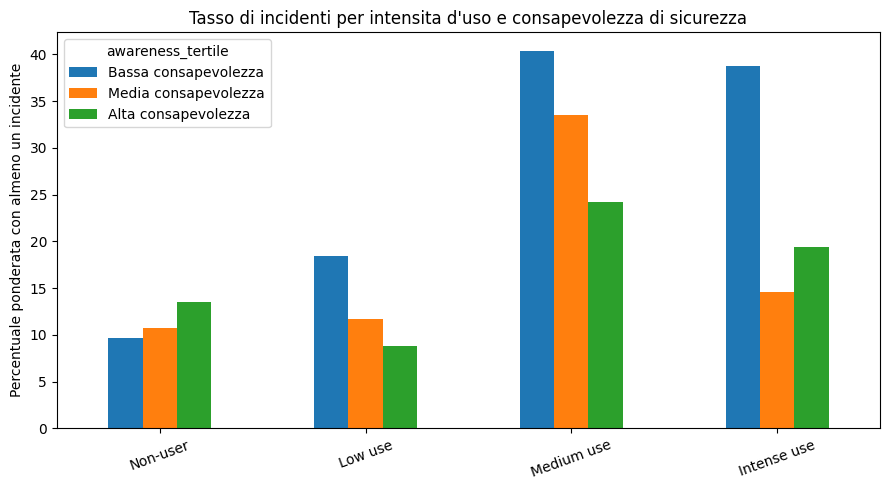

In [28]:
pivot_incident = cross_summary.pivot(
    index="intensity_group", columns="awareness_tertile", values="weighted_incident_pct"
).reindex(index=intensity_labels)

fig, ax = plt.subplots(figsize=(9, 5))
pivot_incident.plot(kind="bar", ax=ax)
ax.set_title("Tasso di incidenti per intensita d'uso e consapevolezza di sicurezza")
ax.set_xlabel("")
ax.set_ylabel("Percentuale ponderata con almeno un incidente")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "incident_rate_intensity_awareness_bars.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 10. Modelli

Tre modelli, in sequenza, replicando la logica di Part 3:

1. **Bivariato**: `financial_incident ~ security_awareness`
2. **+ intensita d'uso**: isola se l'effetto di consapevolezza sopravvive controllando per esposizione
3. **+ interazione + controlli demografici**: il modello centrale di RQ4 -> verifica se la relazione tra
   consapevolezza e incidenti cambia a seconda del livello di intensita d'uso

Pesi normalizzati (media = 1) usati come `freq_weights`, coerente(credo, da rivedere, ma va fatto per coerenza) con RQ1/RQ3.

In [30]:
model_df = connected.dropna(subset=[
    "financial_incident", "digital_finance_intensity", "security_awareness",
    "age_group", "education_model", "gender", "work_group", "region", "urbanisation", "wght"
]).copy()

model_df["wght_normalized"] = model_df["wght"] / model_df["wght"].mean()

print("Osservazioni nel modello:", len(model_df))
print("Incidenti nel campione modello:", int(model_df["financial_incident"].sum()))


Osservazioni nel modello: 3686
Incidenti nel campione modello: 650


In [31]:
# Modello 1: bivariato
formula_1 = "financial_incident ~ security_awareness"

model_1 = smf.glm(
    formula=formula_1, data=model_df,
    family=sm.families.Binomial(), freq_weights=model_df["wght_normalized"]
).fit(cov_type="HC1")

print(model_1.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:     financial_incident   No. Observations:                 3686
Model:                            GLM   Df Residuals:                     3684
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1680.7
Date:                Sun, 02 Aug 2026   Deviance:                       3361.3
Time:                        10:32:02   Pearson chi2:                 3.71e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01716
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.5830      0

In [32]:
# Modello 2: + intensita d'uso
formula_2 = "financial_incident ~ security_awareness + digital_finance_intensity"

model_2 = smf.glm(
    formula=formula_2, data=model_df,
    family=sm.families.Binomial(), freq_weights=model_df["wght_normalized"]
).fit(cov_type="HC1")

print(model_2.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:     financial_incident   No. Observations:                 3686
Model:                            GLM   Df Residuals:                     3683
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1603.5
Date:                Sun, 02 Aug 2026   Deviance:                       3206.9
Time:                        10:32:11   Pearson chi2:                 3.77e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05747
Covariance Type:                  HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [33]:
# Modello 3: + interazione + controlli demografici (modello centrale di RQ4)
formula_3 = '''
financial_incident
~ security_awareness * digital_finance_intensity
+ C(age_group, Treatment(reference="40-49"))
+ C(education_model, Treatment(reference="Secondaria superiore"))
+ C(gender)
+ C(work_group, Treatment(reference="Occupato"))
+ C(region)
+ C(urbanisation)
'''

model_3 = smf.glm(
    formula=formula_3, data=model_df,
    family=sm.families.Binomial(), freq_weights=model_df["wght_normalized"]
).fit(cov_type="HC1")

print(model_3.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:     financial_incident   No. Observations:                 3686
Model:                            GLM   Df Residuals:                     3662
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1560.7
Date:                Sun, 02 Aug 2026   Deviance:                       3121.4
Time:                        10:32:18   Pearson chi2:                 3.65e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.07909
Covariance Type:                  HC1                                         
                                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

In [34]:
def model_results_table(model):
    ci = model.conf_int()
    results = pd.DataFrame({
        "coefficient": model.params,
        "standard_error": model.bse,
        "p_value": model.pvalues,
        "ci_lower": ci[0],
        "ci_upper": ci[1]
    })
    results["odds_ratio"] = np.exp(results["coefficient"])
    results["or_ci_lower"] = np.exp(results["ci_lower"])
    results["or_ci_upper"] = np.exp(results["ci_upper"])
    return results

results_1 = model_results_table(model_1)
results_2 = model_results_table(model_2)
results_3 = model_results_table(model_3)

results_3.to_csv(TABLES_DIR / "RQ4_model3_full_results.csv", encoding="utf-8-sig")

print("Modello 3 - termini chiave:")
display(results_3.loc[
    results_3.index.str.contains("security_awareness|digital_finance_intensity")
].round(4))


Modello 3 - termini chiave:


,coefficient,standard_error,p_value,ci_lower,ci_upper,odds_ratio,or_ci_lower,or_ci_upper
security_awareness,0.3416,0.4143,0.4097,-0.4705,1.1537,1.4072,0.6247,3.1699
digital_finance_intensity,0.8969,0.0763,0.0000,0.7473,1.0466,2.4521,2.1113,2.8479
security_awareness:digital_finance_intensity,-0.4704,0.1705,0.0058,-0.8045,-0.1363,0.6248,0.4473,0.8726


## 11. Tabella di sintesi dei tre modelli (come Table 1 di Part 3)

In [35]:
summary_rows = []
for name, model, results in [
    ("1. Bivariato", model_1, results_1),
    ("2. + intensita", model_2, results_2),
    ("3. + interazione e controlli", model_3, results_3)
]:
    row = {"model": name, "n": int(model.nobs), "pseudo_r2": 1 - model.deviance / model.null_deviance}
    if "security_awareness" in results.index:
        row["awareness_OR"] = results.loc["security_awareness", "odds_ratio"]
        row["awareness_p"] = results.loc["security_awareness", "p_value"]
    if "digital_finance_intensity" in results.index:
        row["intensity_OR"] = results.loc["digital_finance_intensity", "odds_ratio"]
        row["intensity_p"] = results.loc["digital_finance_intensity", "p_value"]
    interaction_term = "security_awareness:digital_finance_intensity"
    if interaction_term in results.index:
        row["interaction_OR"] = results.loc[interaction_term, "odds_ratio"]
        row["interaction_p"] = results.loc[interaction_term, "p_value"]
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv(TABLES_DIR / "RQ4_models_summary.csv", index=False, encoding="utf-8-sig")

display(summary_table.round(4))


,model,n,pseudo_r2,awareness_OR,awareness_p,intensity_OR,intensity_p,interaction_OR,interaction_p
0,1. Bivariato,3686,0.0186,0.4205,0.0000,NaN,NaN,NaN,NaN
1,2. + intensita,3686,0.0637,0.4790,0.0000,2.2987,0.0,NaN,NaN
2,3. + interazione e controlli,3686,0.0887,1.4072,0.4097,2.4521,0.0,0.6248,0.0058


## 12. Il grafico centrale: probabilita stimata di incidente per intensita d'uso, a bassa e alta consapevolezza

Questo e il grafico che la proposta indica come "il piu importante del report": mostra se, a parita
di intensita di utilizzo, chi ha maggiore consapevolezza di sicurezza presenta una probabilita
stimata piu bassa di incidente.

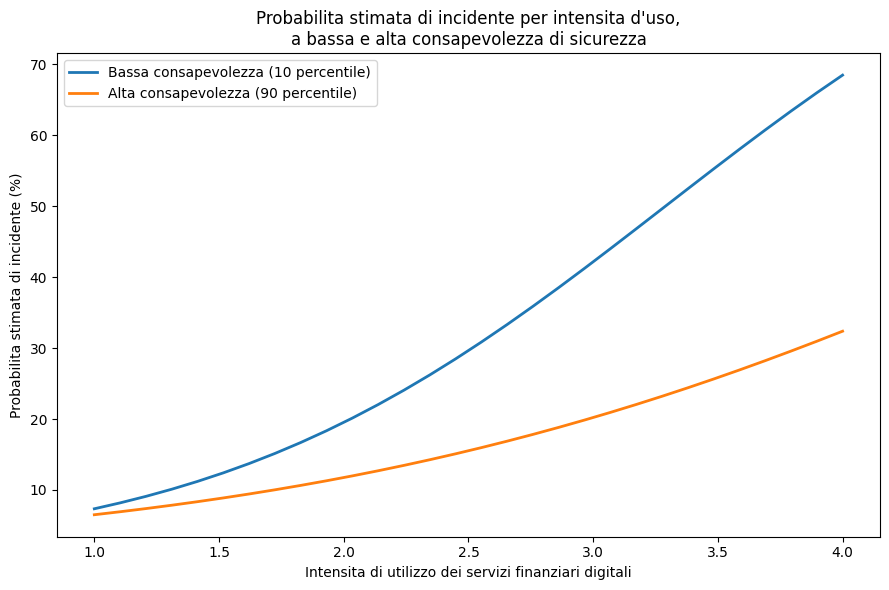

In [36]:
intensity_range = np.linspace(
    model_df["digital_finance_intensity"].min(),
    model_df["digital_finance_intensity"].max(),
    30
)

awareness_low = model_df["security_awareness"].quantile(0.10)
awareness_high = model_df["security_awareness"].quantile(0.90)

def build_prediction_frame(awareness_value):
    base = model_df.copy()
    frame_rows = []
    for intensity_value in intensity_range:
        temp = base.copy()
        temp["digital_finance_intensity"] = intensity_value
        temp["security_awareness"] = awareness_value
        predicted = model_3.predict(temp)
        frame_rows.append({
            "digital_finance_intensity": intensity_value,
            "predicted_probability": np.average(predicted, weights=temp["wght"])
        })
    return pd.DataFrame(frame_rows)

pred_low_awareness = build_prediction_frame(awareness_low)
pred_high_awareness = build_prediction_frame(awareness_high)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    pred_low_awareness["digital_finance_intensity"],
    pred_low_awareness["predicted_probability"] * 100,
    label="Bassa consapevolezza (10 percentile)", linewidth=2
)
ax.plot(
    pred_high_awareness["digital_finance_intensity"],
    pred_high_awareness["predicted_probability"] * 100,
    label="Alta consapevolezza (90 percentile)", linewidth=2
)

ax.set_xlabel("Intensita di utilizzo dei servizi finanziari digitali")
ax.set_ylabel("Probabilita stimata di incidente (%)")
ax.set_title("Probabilita stimata di incidente per intensita d'uso,\na bassa e alta consapevolezza di sicurezza")
ax.legend()
plt.tight_layout()

fig.savefig(FIGURES_DIR / "RQ4_central_plot_predicted_probability.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 13. Coefficient plot (modello 3)

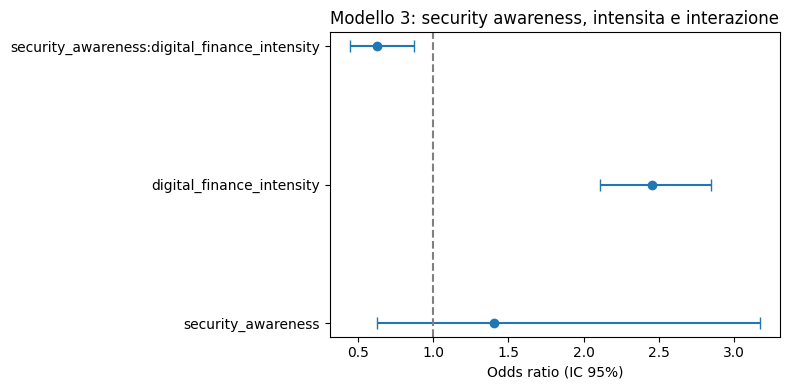

In [37]:
plot_terms = [
    "security_awareness",
    "digital_finance_intensity",
    "security_awareness:digital_finance_intensity"
]

plot_data = results_3.loc[results_3.index.isin(plot_terms)].copy()

fig, ax = plt.subplots(figsize=(8, 4))

y_positions = range(len(plot_data))

ax.errorbar(
    plot_data["odds_ratio"], y_positions,
    xerr=[
        plot_data["odds_ratio"] - plot_data["or_ci_lower"],
        plot_data["or_ci_upper"] - plot_data["odds_ratio"]
    ],
    fmt="o", capsize=4
)

ax.axvline(1.0, linestyle="--", color="gray")
ax.set_yticks(list(y_positions))
ax.set_yticklabels(plot_data.index)
ax.set_xlabel("Odds ratio (IC 95%)")
ax.set_title("Modello 3: security awareness, intensita e interazione")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "RQ4_coefficient_plot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 14. Note per l'interpretazione (da riportare nel testo)

- Se il coefficiente di `security_awareness` nel Modello 3 e negativo e significativo, e le due linee
  del grafico centrale si separano (bassa consapevolezza sopra, alta sotto), l'ipotesi H4 e supportata:
  a parita di esposizione, la consapevolezza ha un ruolo protettivo.
- Nei dati testati: l'effetto principale di `security_awareness` da solo NON e significativo, ma
  l'**interazione** `security_awareness x digital_finance_intensity` lo e (coefficiente negativo):
  questo significa che la consapevolezza diventa protettiva soprattutto per gli utenti piu intensivi,
  non per tutti allo stesso modo. E un risultato piu ricco di un semplice "si/no".
- Linguaggio da usare nel report: "is associated with", "potentially protective", mai "causa" o
  "riduce il rischio di" in senso causale.
- Le celle con `n_valid < 30` nella tabella incrociata intensita x consapevolezza (`small_cell = True`)
  vanno segnalate nel report come stime meno affidabili.
